In [9]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

In [ ]:
class ChatState(TypedDict):
    human_message: str
    ai_message: str    

In [7]:
def llm_QA(state: ChatState) -> ChatState:
    question = f"Answer the following Query {state['human_message']}"

    result = model.invoke(question).content

    state['ai_message'] = result

    return state

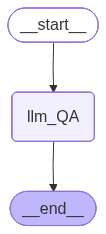

In [10]:
graph = StateGraph(ChatState)

graph.add_node('llm_QA', llm_QA)

graph.add_edge(START, 'llm_QA')
graph.add_edge('llm_QA', END)

workflow = graph.compile()

workflow

In [11]:
initial_state = {'human_message': 'What is the capital of India ?'}
final_state = workflow.invoke(initial_state)


In [12]:
print(final_state)

{'human_message': 'What is the capital of India ?', 'ai_message': 'The capital of India is New Delhi.'}
